In [ ]:
# importing the csv file into a pandas dataframe
import pandas as pd

df = pd.read_csv("statcast_clean_2026.csv")

df.shape
df["description"].value_counts()

description
ball                       194057
foul                       103507
hit_into_play              100249
called_strike               92919
swinging_strike             59190
blocked_ball                12018
foul_tip                     6043
swinging_strike_blocked      3174
automatic_ball               1802
hit_by_pitch                 1690
foul_bunt                    1221
missed_bunt                   207
automatic_strike               68
pitchout                       31
bunt_foul_tip                  22
swinging_pitchout               1
Name: count, dtype: int64

In [ ]:
# Defining the different types of swing outcomes needed for this project
swing_outcomes = [
    "swinging_strike",
    "swinging_strike_blocked",
    "foul",
    "foul_tip",
    "hit_into_play"
]

In [3]:
# Filtering the dataframe to only include the defined swing outcomes
df = df[df["description"].isin(swing_outcomes)].copy()
df.shape
df["description"].value_counts()

description
foul                       103507
hit_into_play              100249
swinging_strike             59190
foul_tip                     6043
swinging_strike_blocked      3174
Name: count, dtype: int64

In [4]:
# Creating a new column 'whiff' to indicate swinging strikes. This is the target variable
df["whiff"] = df["description"].isin([
    "swinging_strike",
    "swinging_strike_blocked"
]).astype(int)
df["whiff"].value_counts()
df["whiff"].value_counts(normalize=True)

whiff
0    0.770858
1    0.229142
Name: proportion, dtype: float64

In [5]:
# Listing all the columns in the dataframe to understand the available features
df.columns.tolist()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [6]:
# Defining the features to be used for modeling
features = [
    "pitch_type",
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "plate_x",
    "plate_z",
    "balls",
    "strikes",
    "stand",
    "p_throws",
    "whiff"
]

df[features].head()

,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,release_pos_x,release_pos_z,release_extension,plate_x,plate_z,balls,strikes,stand,p_throws,whiff
2,SI,91.9,2330.0,-1.71,-0.19,-2.77,5.12,6.1,-0.402039,1.666734,1,0,L,R,0
6,CH,83.3,1315.0,1.18,-0.33,2.99,5.51,6.4,0.914570,1.826710,2,2,R,L,1
8,ST,86.4,2243.0,-0.99,-0.33,2.53,5.68,5.5,-0.197743,2.184160,0,1,R,L,0
9,SI,92.4,2316.0,-1.62,0.16,-2.71,5.16,6.1,0.047614,1.697295,1,1,L,R,0
14,FC,84.2,2567.0,0.26,0.97,-2.28,5.15,6.9,0.372112,1.964053,0,1,R,R,0


In [7]:
# Checking for missing values in the selected features
df[features].isna().sum()

pitch_type           110
release_speed        111
release_spin_rate    598
pfx_x                110
pfx_z                110
release_pos_x        110
release_pos_z        110
release_extension    397
plate_x              110
plate_z              110
balls                  0
strikes                0
stand                  0
p_throws               0
whiff                  0
dtype: int64

In [8]:
# Getting a statistical summary of the selected features
df[features].describe()

,release_speed,release_spin_rate,pfx_x,pfx_z,release_pos_x,release_pos_z,release_extension,plate_x,plate_z,balls,strikes,whiff
count,272052.000000,271565.000000,272053.000000,272053.000000,272053.000000,272053.000000,271766.000000,272053.000000,272053.000000,272163.000000,272163.000000,272163.000000
mean,89.834407,2260.115645,-0.138582,0.582963,-0.703503,5.725003,6.438357,0.021484,2.299044,1.025757,1.087984,0.229142
std,6.108345,373.097585,0.902807,0.694849,1.947103,0.510401,0.452127,0.589618,0.725101,0.988491,0.811395,0.420282
min,30.600000,15.000000,-2.920000,-1.860000,-4.900000,1.060000,2.800000,-3.028014,-1.715042,0.000000,0.000000,0.000000
25%,85.700000,2122.000000,-0.920000,0.130000,-2.090000,5.460000,6.200000,-0.383840,1.809285,0.000000,0.000000,0.000000
50%,90.700000,2303.000000,-0.220000,0.620000,-1.480000,5.760000,6.500000,0.017886,2.319017,1.000000,1.000000,0.000000
75%,94.600000,2475.000000,0.590000,1.180000,1.210000,6.040000,6.700000,0.420832,2.813759,2.000000,2.000000,0.000000
max,105.500000,3599.000000,2.300000,2.480000,5.080000,7.730000,8.600000,3.227179,5.277250,3.000000,2.000000,1.000000


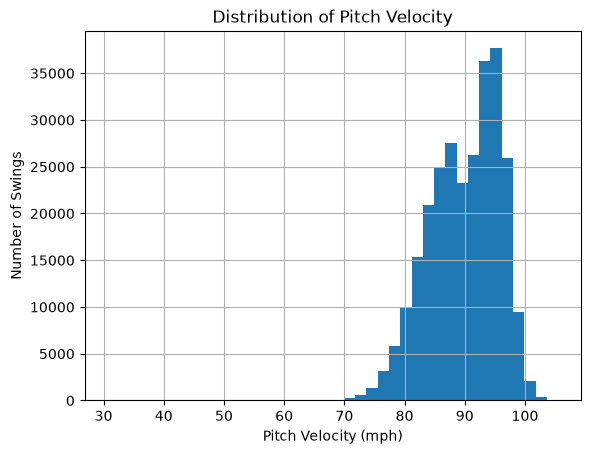

In [9]:
# Plotting the distribution of pitch velocity (release speed)
import matplotlib.pyplot as plt

df["release_speed"].hist(bins=40)

plt.xlabel("Pitch Velocity (mph)")
plt.ylabel("Number of Swings")
plt.title("Distribution of Pitch Velocity")
plt.show()

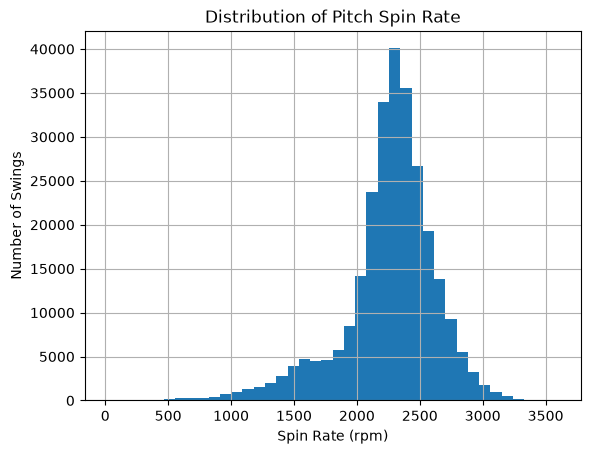

In [10]:
# Plotting the distribution of pitch spin rate
df["release_spin_rate"].hist(bins=40)

plt.xlabel("Spin Rate (rpm)")
plt.ylabel("Number of Swings")
plt.title("Distribution of Pitch Spin Rate")
plt.show()

In [11]:
# Filtering the dataframe to remove rows with missing values in the selected features
features = [
    "pitch_type",
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "plate_x",
    "plate_z",
    "balls",
    "strikes",
    "stand",
    "p_throws"
]

df_model = df.dropna(subset=features).copy()

In [12]:
# Checking the shape of the filtered dataframe to see how many rows and columns remain after removing missing values
df_model.shape

(271362, 120)

In [14]:
# Selecting the features and target variable for modeling
X = df_model[features]
y = df_model["whiff"]

X.shape, y.shape

((271362, 14), (271362,))

In [15]:
# Defining categorical features for modeling
categorical_features = ["pitch_type", "stand", "p_throws"]

In [16]:
# Defining numeric features for modeling
numeric_features = [
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "plate_x",
    "plate_z",
    "balls",
    "strikes"
]

In [17]:
# Setting up a preprocessor to handle both numeric and categorical features using scikit-learn's ColumnTransformer. Numeric features will be standardized using StandardScaler, while categorical features will be one-hot encoded using OneHotEncoder.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [18]:
# Splitting the dataset into training and testing sets using scikit-learn's train_test_split function. The test set will be 20% of the total data, and the split will be stratified based on the target variable 'whiff' to ensure that both classes are represented proportionally in both sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Checking the shapes of the training and testing sets to confirm the split
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((217089, 14), (54273, 14), (217089,), (54273,))

In [20]:
# Implementing a baseline model using scikit-learn's DummyClassifier. This model will predict the most frequent class in the training set, providing a benchmark for evaluating more complex models.
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_accuracy = baseline.score(X_test, y_test)

baseline_accuracy

0.7708252722348129

In [21]:
# Setting up a logistic regression model using scikit-learn's Pipeline. The pipeline will first preprocess the data using the defined preprocessor and then fit a logistic regression classifier to the training data.
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [22]:
# Fitting the logistic regression model and making predictions
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

In [23]:
# Evaluating the performance of the logistic regression model using accuracy, precision, recall, and F1 score metrics from scikit-learn.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Accuracy: 0.7798352772096623
Precision: 0.9421338155515371
Recall: 0.04188776330599775
F1 Score: 0.08020937572165346


In [ ]:
# Evaluating the performance of the logistic regression model using a confusion matrix.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

cm

array([[41803,    32],
       [11917,   521]])

In [25]:
# Setting up a random forest classifier using scikit-learn's Pipeline. The pipeline will first preprocess the data using the defined preprocessor and then fit a random forest classifier to the training data.
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [26]:
# Fitting the random forest model and making predictions
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

In [27]:
# Evaluating the performance of the random forest model using accuracy, precision, recall, and F1 score metrics from scikit-learn.
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8118769922429201
Precision: 0.7123522683949676
Recall: 0.300450233156456
F1 Score: 0.42264193621352636


In [ ]:
# Evaluating the performance of the random forest model using a confusion matrix.
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[40326,  1509],
       [ 8701,  3737]])

In [29]:
# Calculating the ROC AUC score for the random forest model to evaluate its performance in distinguishing between the two classes (whiff and no whiff). The ROC AUC score provides a measure of how well the model can separate the positive class from the negative class across different threshold values.
from sklearn.metrics import roc_auc_score

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

roc_auc_rf

0.7744667116484711

In [30]:
# Calculating the ROC AUC score for the logistic regression model to evaluate its performance in distinguishing between the two classes (whiff and no whiff). The ROC AUC score provides a measure of how well the model can separate the positive class from the negative class across different threshold values.
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

roc_auc_logistic


0.6534397060958147

In [31]:
# Getting the feature names from the preprocessor to understand which features were used in the random forest model. This is important for interpreting the model's predictions and understanding the contribution of each feature.
feature_names = random_forest.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['num__release_speed', 'num__release_spin_rate', 'num__pfx_x',
       'num__pfx_z', 'num__release_pos_x', 'num__release_pos_z',
       'num__release_extension', 'num__plate_x', 'num__plate_z',
       'num__balls', 'num__strikes', 'cat__pitch_type_CH',
       'cat__pitch_type_CS', 'cat__pitch_type_CU', 'cat__pitch_type_EP',
       'cat__pitch_type_FA', 'cat__pitch_type_FC', 'cat__pitch_type_FF',
       'cat__pitch_type_FO', 'cat__pitch_type_FS', 'cat__pitch_type_KC',
       'cat__pitch_type_KN', 'cat__pitch_type_SI', 'cat__pitch_type_SL',
       'cat__pitch_type_ST', 'cat__pitch_type_SV', 'cat__stand_L',
       'cat__stand_R', 'cat__p_throws_L', 'cat__p_throws_R'], dtype=object)

In [32]:
# Getting the feature importances from the random forest model to understand which features had the most influence on the model's predictions. Feature importances provide insight into the relative importance of each feature in making predictions.
importances = random_forest.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
8,num__plate_z,0.223069
7,num__plate_x,0.122539
1,num__release_spin_rate,0.087071
0,num__release_speed,0.086144
4,num__release_pos_x,0.084354
3,num__pfx_z,0.084015
2,num__pfx_x,0.081870
5,num__release_pos_z,0.081741
6,num__release_extension,0.059513
10,num__strikes,0.022154


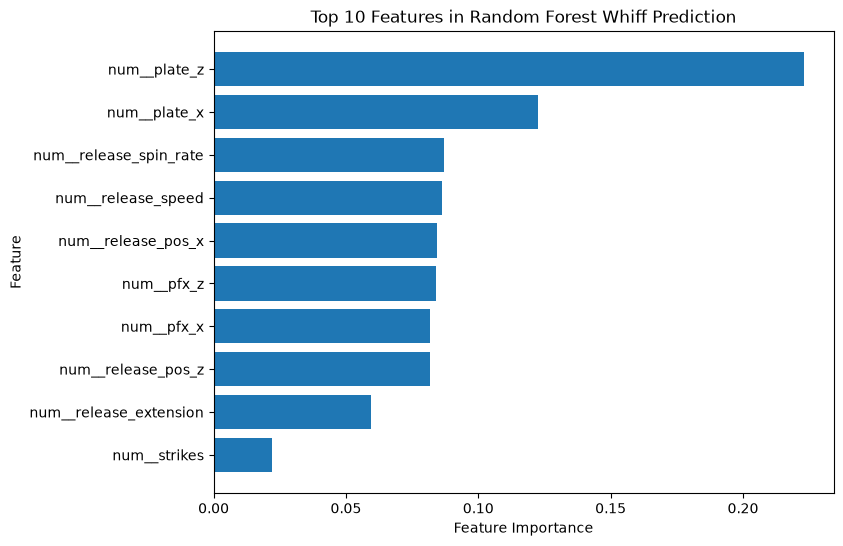

In [33]:
# Visualizing the top 10 features in the random forest model to understand which features had the most influence on the model's predictions. A horizontal bar chart is used to display the feature importances, making it easy to compare the relative importance of each feature.
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features in Random Forest Whiff Prediction")
plt.show()

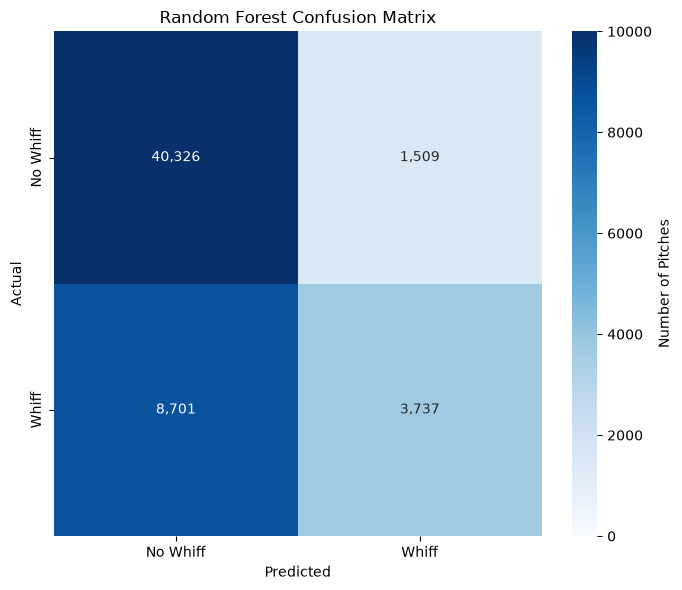

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    vmin=0,
    vmax=10000,
    xticklabels=["No Whiff", "Whiff"],
    yticklabels=["No Whiff", "Whiff"],
    cbar_kws={"label": "Number of Pitches"}
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()